## Task
* use your webcam to take >15 photos of yourself. Show a series of emotions, but make sure that some are happy and some are sad (take my pictures in train/faces if you have no camera)
* prepare the data by slicing it close to your face and average the three color channels (use cmap='gray' for imshow after the averaging)
* create a vector that is categorizing your data (sad or happy)
* resample (the optimum slice) of your images to be 32x32 pixels using cv2 and normalize them by dividing with 255
* Create a Convolutional neural network with one or two hidden layers and train it on your data.
* Then extract the  weights with:<br>
  ```weights=face_model.layers[0].get_weights()[0]```<br>
  ```weights=weights.mean(axis=0).mean(axis=0).mean(axis=0)```<br>
* Normalize them and plot them.
* Where in the image lays the highest values (highest focus)? How does this change with your choice of size of the network?
* Check the prediction for few of your pictures with ```face_model.predict```
  

In [ ]:
import zipfile
import sys,os
import numpy as np
import cv2
import keras

from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import LeakyReLU
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# Load the images
uploaded = ~Users/rebbe/Master/BERN02/Neural_networks/faces.zip

Saving faces.zip to faces.zip


In [ ]:
# unzip the uploaded folder
with zipfile.ZipFile("faces.zip", "r") as zip_ref:
    zip_ref.extractall("faces")

Shape of WIN_20251015_09_27_38_Pro.jpg: (541, 379, 3)
Shape of WIN_20251015_09_27_40_Pro.jpg: (489, 341, 3)
Shape of WIN_20251015_09_27_41_Pro (2).jpg: (469, 338, 3)
Shape of WIN_20251015_09_27_41_Pro.jpg: (496, 346, 3)
Shape of WIN_20251015_09_27_42_Pro.jpg: (465, 353, 3)
Shape of WIN_20251015_09_27_43_Pro (2).jpg: (477, 361, 3)
Shape of WIN_20251015_09_27_43_Pro.jpg: (457, 357, 3)
Shape of WIN_20251015_09_27_45_Pro.jpg: (383, 287, 3)
Shape of WIN_20251015_09_27_47_Pro.jpg: (467, 363, 3)
Shape of WIN_20251015_09_27_49_Pro.jpg: (458, 358, 3)
Shape of WIN_20251015_09_27_50_Pro.jpg: (482, 394, 3)
Shape of WIN_20251015_09_27_54_Pro.jpg: (585, 468, 3)
Shape of WIN_20251015_09_27_56_Pro.jpg: (637, 455, 3)
Shape of WIN_20251015_09_27_57_Pro.jpg: (629, 455, 3)
Shape of WIN_20251015_09_28_00_Pro.jpg: (545, 371, 3)
Shape of WIN_20251015_09_28_01_Pro.jpg: (528, 372, 3)
Shape of WIN_20251015_09_28_02_Pro (2).jpg: (550, 370, 3)
Shape of WIN_20251015_09_28_02_Pro.jpg: (528, 391, 3)
Shape of WIN_202

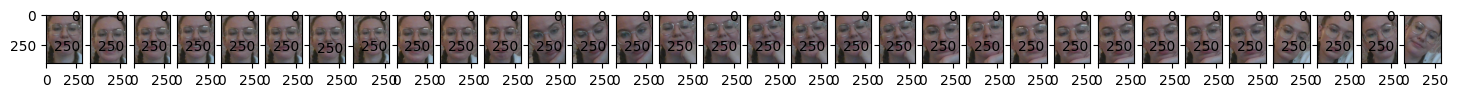

In [ ]:
from matplotlib import image
path_to_files = "faces"
data=[]
list_of_files=os.listdir(os.sep.join([path_to_files,'faces']))
for filename in sorted(list_of_files):
    img = image.imread(os.sep.join([path_to_files,'faces',filename]))
    print(f"Shape of {filename}: {img.shape}")
    # Dynamically calculate slicing dimensions to extract the central part
    height, width, _ = img.shape
    start_row = max(0, height // 2 - 200)
    end_row = min(height, height // 2 + 200)
    start_col = max(0, width // 2 - 150)
    end_col = min(width, width // 2 + 150)
    cropped_img = img[start_row:end_row, start_col:end_col, :]

    data.append(cropped_img)

axis_list=[]
fig,ax=plt.subplots(1,len(data),figsize=(18,8))
for i,img in enumerate(data):
    ax[i].imshow(img,cmap='gray')

# 32 images, 1 = happy, 0 = sad
happy=np.array([1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1])

# Ensure the number of happy labels matches the number of images
if len(happy) != len(data):
    raise ValueError("Number of happy labels does not match the number of images")


data=[cv2.resize(img.mean(axis=2)/255,dsize=(36,36)) for img in data]
data=np.array(data)
label=np.vstack((happy,np.negative(happy)+1)).T

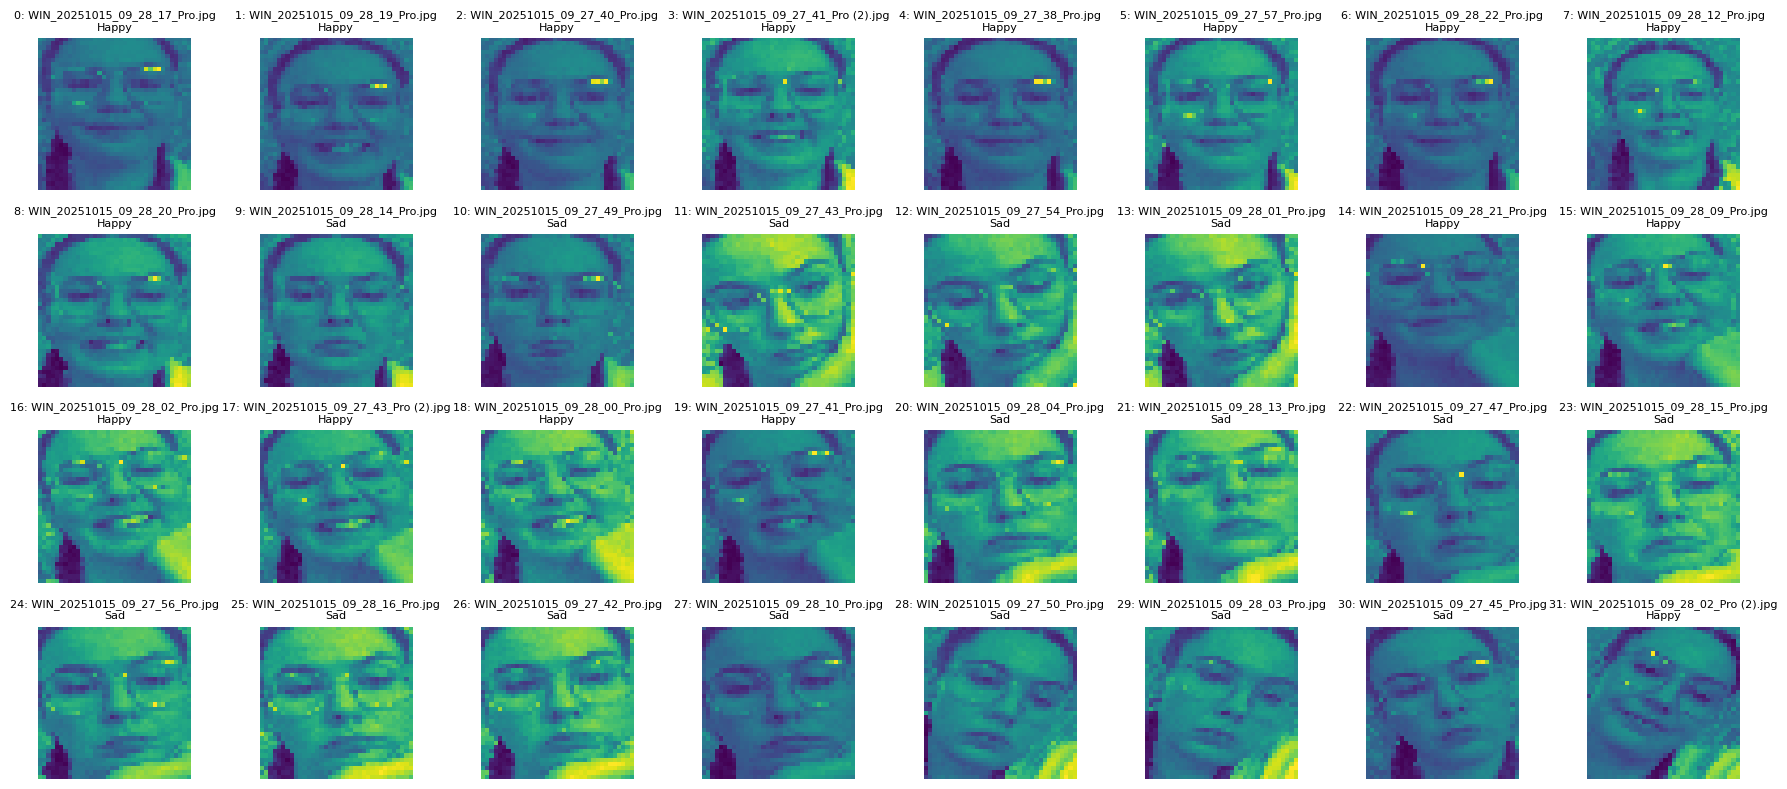

In [ ]:
# Print the images with labels to make sure they are labeled correctly
fig, axes = plt.subplots(4, 8, figsize=(18, 8))
axes = axes.ravel()

for i, (img, fname, lbl) in enumerate(zip(data, list_of_files, happy)):
    label_text = "Happy" if lbl == 1 else "Sad"
    axes[i].imshow(img)
    axes[i].set_title(f"{i}: {fname}\n{label_text}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Set modelling parameter

epochs = 50     # Total throughput
num_classes = 2 # Categories

face_model = Sequential()
face_model.add(Conv2D(36, kernel_size=(3,3),activation='linear',input_shape=(36,36,1),padding='same'))
face_model.add(LeakyReLU(alpha=0.1))
face_model.add(Conv2D(72, (1, 1), activation='linear',padding='same'))
face_model.add(LeakyReLU(alpha=0.1))
face_model.add(Flatten())
face_model.add(Dense(num_classes, activation='softmax'))
face_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
face_model.summary()
face_train = face_model.fit(data, label, epochs=epochs,verbose=1)
#bird_model.save("bird_model_with_dropout.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 36)     │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 36, 36, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 36, 36, 72)     │         2,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 36, 36, 72)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │       186,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,650 (740.82 KB)

 Trainable params: 189,650 (740.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6953
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.9483
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7230
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.7810
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6250 - loss: 0.5793
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5938 - loss: 0.5600
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6122
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.5759
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9062 - loss: 0.4941
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9375 - loss: 0.4467
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8750 - loss: 0.4488
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8125 - loss: 0.4397
Epo

Text(0.5, 1.0, 'Average filter focus map')

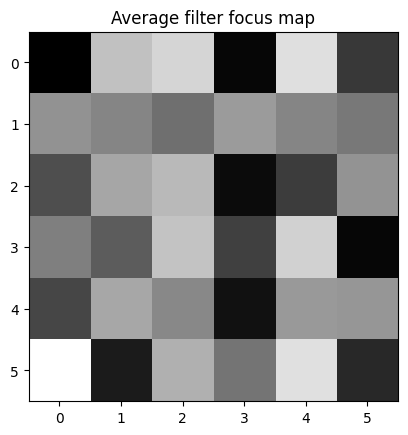

In [ ]:
weights=face_model.layers[0].get_weights()[0]
weights=weights.mean(axis=0).mean(axis=0).mean(axis=0)
reshaped_weights = weights.reshape(6,6)
reshaped_weights-=reshaped_weights.min()
reshaped_weights/=reshaped_weights.max()
plt.imshow(reshaped_weights, cmap='gray')
plt.title("Average filter focus map")



In [ ]:
face_model.predict(data[1:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step


array([[0.9865518 , 0.01344819],
       [0.99679536, 0.00320469],
       [0.9877443 , 0.01225569],
       [0.99697745, 0.00302259]], dtype=float32)

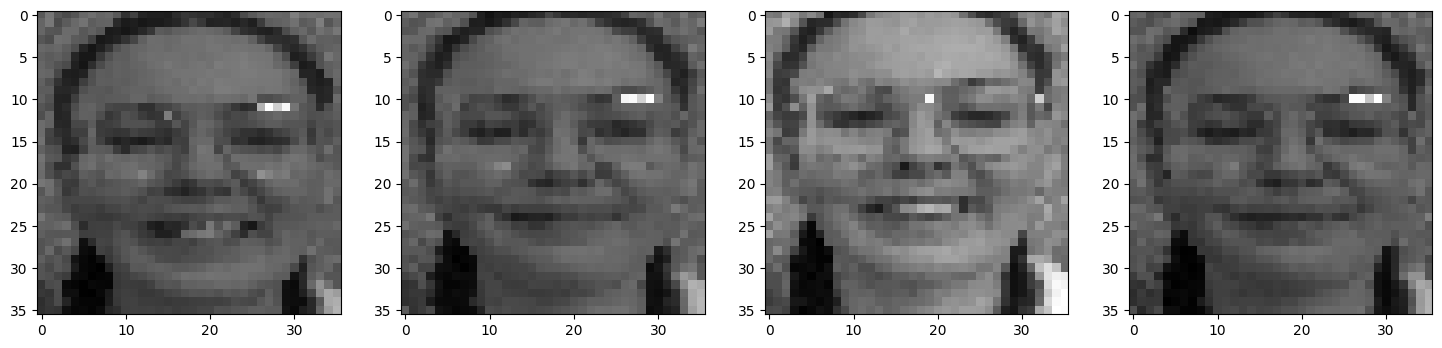

In [ ]:
# Print the pictures predicted above (1:5)
axis_list=[]
fig,ax=plt.subplots(1,4,figsize=(18,8))
for i,img in enumerate(data[1:5]):
    ax[i].imshow(img,cmap='gray')

In [ ]:
face_model.predict(data[10:14])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[0.0374656 , 0.9625345 ],
       [0.01161454, 0.98838544],
       [0.00404293, 0.9959571 ],
       [0.01132805, 0.988672  ]], dtype=float32)

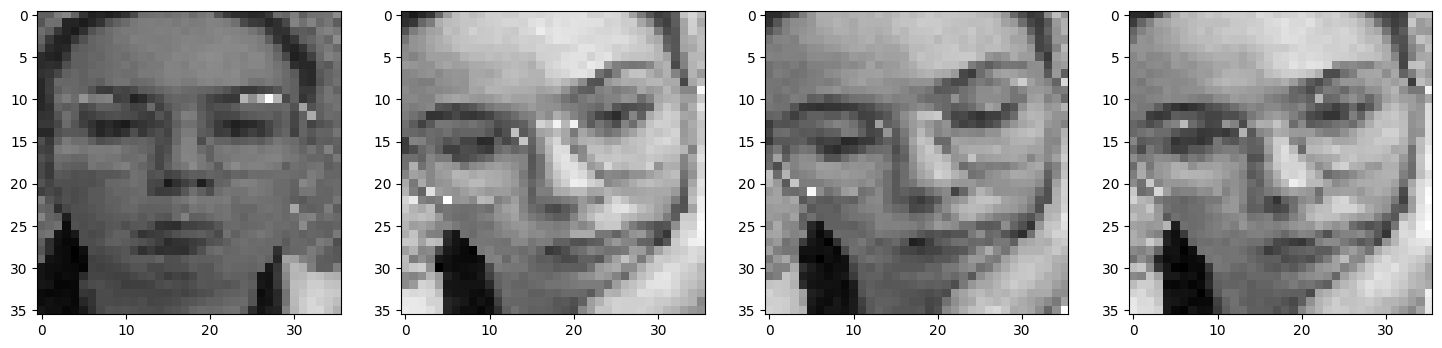

In [ ]:
# Print the pictures predicted above (10:14)
axis_list=[]
fig,ax=plt.subplots(1,4,figsize=(18,8))
for i,img in enumerate(data[10:14]):
    ax[i].imshow(img,cmap='gray')

Again the model confidently makes correct predictions.